# Домашнее задание #8: Деревья решений и случайный лес

**Датасет:** [Used Toyota Corolla Prices](https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars)

**Цель:** обучить случайный лес на предобработанном датасете, сравнить с одним деревом и с линейной регрессией из ДЗ #4.

## Импорты и загрузка данных

In [346]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pygments.lexer import include

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
from collections import Counter


df = pd.read_csv('ToyotaCorolla.csv')
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


---
## 1. Предобработка данных

In [347]:
print(df.shape)
df.info()

(1436, 39)
<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight        

In [348]:
df.describe()

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [349]:
# Пропущенные значения
df.isnull().sum()

Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

### 1.2 Обработка пропусков и категориальных признаков

Данные: 1148 train, 288 test
Корреляция признаков с ценой:
Price                1.000000
Mfg_Year             0.885159
Boardcomputer        0.601292
Automatic_airco      0.588262
Weight               0.581198
CD_Player            0.481374
Airco                0.429259
Powered_Windows      0.356518
Central_Lock         0.343458
HP                   0.314990
ABS                  0.306138
Airbag_2             0.248974
Mistlamps            0.222083
Quarterly_Tax        0.219197
Mfr_Guarantee        0.197802
Doors                0.185326
Sport_Model          0.164121
Guarantee_Period     0.146627
CC                   0.126389
Met_Color            0.108905
Metallic_Rim         0.108564
Backseat_Divider     0.102569
Airbag_1             0.093588
Power_Steering       0.064275
Gears                0.063104
Parking_Assistant    0.044375
Automatic            0.033081
BOVAG_Guarantee      0.028133
Mfg_Month           -0.018138
Radio               -0.041887
Radio_cassette      -0.043179
Tow_Bar    

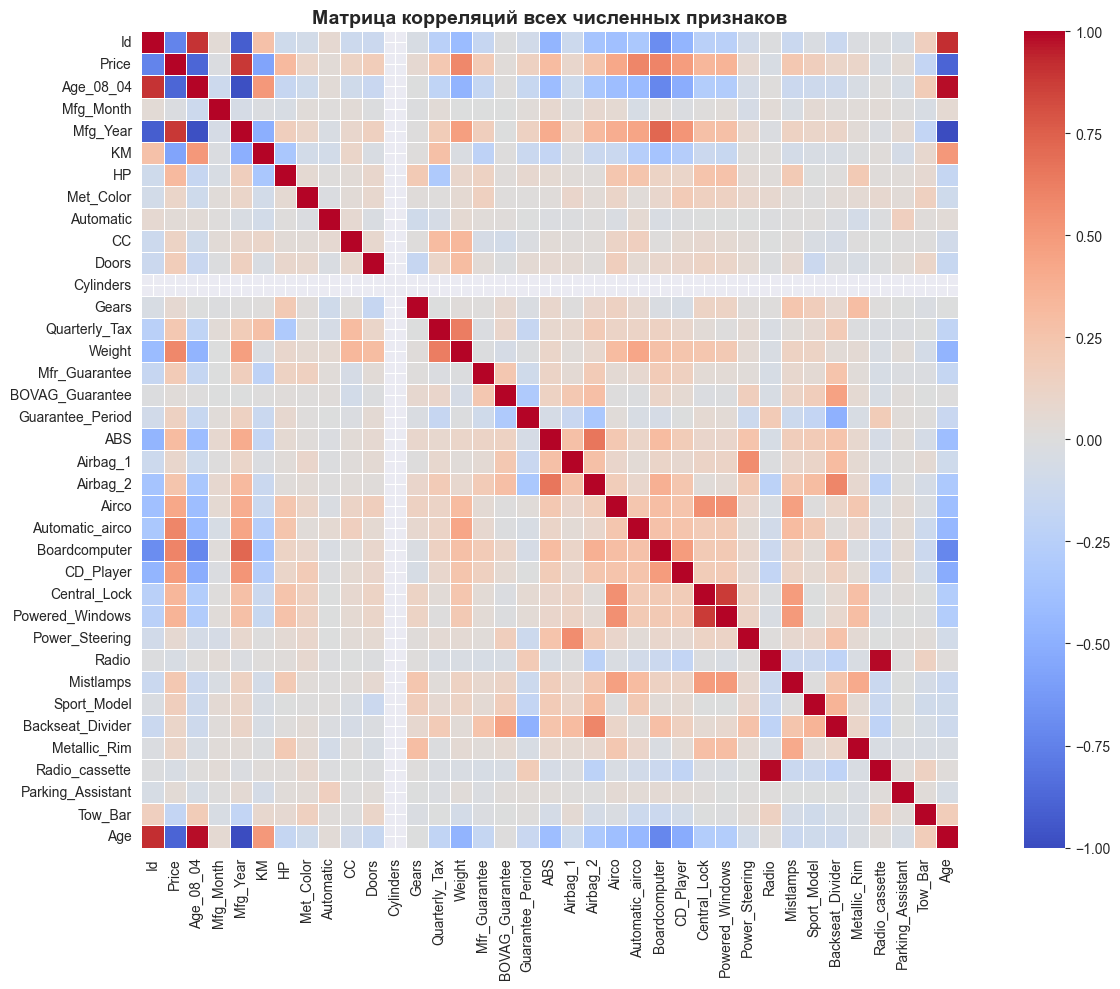

In [350]:
df['Age'] = 2024 - df['Mfg_Year']

numeric_selected = ['Age', 'KM', 'HP', 'Weight', 'Quarterly_Tax', 'Airco', 'Central_Lock']
categorical_selected = ['Model']

features_raw = df[numeric_selected + categorical_selected].copy()
target = df['Price'].copy()

preprocessor_trees = ColumnTransformer([
    ('num', 'passthrough', numeric_selected),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_selected)
])

features_encoded = preprocessor_trees.fit_transform(features_raw)

X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target,
    test_size=0.2,
    random_state=42
)

print(f"Данные: {X_train.shape[0]} train, {X_test.shape[0]} test")


numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr_matrix = df[numeric_cols].corr()

price_corr = corr_matrix['Price'].sort_values(ascending=False)
print("Корреляция признаков с ценой:")
print(price_corr)


plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=False,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Матрица корреляций всех численных признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


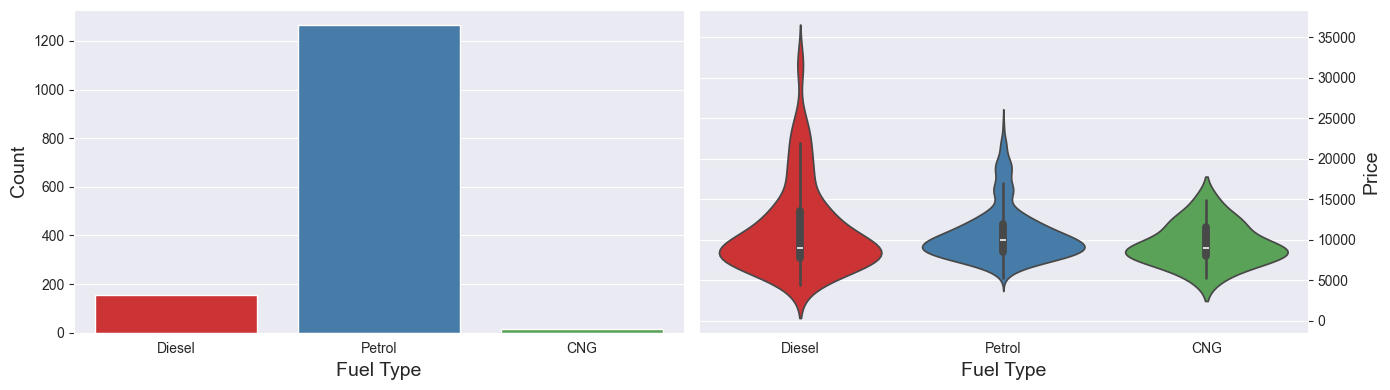

In [351]:
fuel_list= Counter(df['Fuel_Type'])
labels = fuel_list.keys()
sizes = fuel_list.values()

f, axes = plt.subplots(1,2,figsize=(14,4))

sns.countplot(x='Fuel_Type', data=df, ax=axes[0], palette="Set1", hue='Fuel_Type', legend=False)
axes[0].set_xlabel('Fuel Type', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].yaxis.tick_left()

sns.violinplot(x='Fuel_Type', y='Price', data=df, ax=axes[1], hue='Fuel_Type', palette="Set1", legend=False)
axes[1].set_xlabel('Fuel Type', fontsize=14)
axes[1].set_ylabel('Price', fontsize=14)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.tight_layout()
plt.show()

### 📝 Вопрос: Предобработка для случайного леса vs линейной модели

> Для случайного леса предобработка минимальна:
Нормализация не нужна.
Кодирование категориальных признаков:
   технически деревья могут работать с метками, но sklearn требует числового ввода. В отличие от линейной регрессии, для деревьев порядок чисел не важен, поэтому строгих требований к кодированию нет.
Удалять выбросы не нужно. Случайный лес устойчив к выбросам, потому что каждое дерево обучается на случайной подвыборке, а итоговый прогноз усредняется по множеству деревьев.

> Для линейной регрессии предобработка строже:
Стандартизация обязательна.
OneHotEncoder предпочтительнее для категориальных признаков, чтобы модель не интерпретировала числа как порядок.
Выбросы критичны, так как они сильно искажают коэффициенты регрессии.

---
## 2. Разделение выборки

In [352]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,)

print(f'Train: {X_train.shape[0]} объектов')
print(f'Test:  {X_test.shape[0]} объектов')

Train: 1148 объектов
Test:  288 объектов


### 📝 Вопросы про разделение выборки

> **Как вы разделили выборку?**  
> Я использовала функцию train_test_split из sklearn с параметрами: test_size=0.2 (20% данных на тестовую выборку, 80% на обучающую).
>
> **На сколько частей делить выборку при кросс-валидации?**  
> Стандартный подход — 5 частей. Для меньших датасетов можно использовать 10-fold CV для более стабильной оценки. Для очень больших датасетов(>50-100 тыс. строк) иногда достаточно 3-fold или же одного разделения.
>
> **Можно ли обойтись без кросс-валидации?**  
> Да, можно, если очень большой датасет, где одно разделение даёт достоверную оценку. Однако для финальной оценки модели и сравнения алгоритмов кросс-валидация рекомендуется, потому что она даёт более надёжную оценку качества, снижает риск случайного «удачного» разделения и позволяет оценить стабильность модели через стандартное отклонение метрик по фолдам.

---
## 3. Baseline

In [353]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

rmse_dummy = mean_squared_error(y_test, y_pred_dummy)
mae_dummy  = mean_absolute_error(y_test, y_pred_dummy)
r2_dummy   = r2_score(y_test, y_pred_dummy)

print(f'Baseline RMSE: {rmse_dummy:.2f}')
print(f'Baseline MAE:  {mae_dummy:.2f}')
print(f'Baseline R²:   {r2_dummy:.4f}')

Baseline RMSE: 15358356.02
Baseline MAE:  2827.94
Baseline R²:   -0.0061


---
## 4. Одно дерево решений

In [354]:
MAX_DEPTH = 8

t0 = time.time()
tree = DecisionTreeRegressor(max_depth=MAX_DEPTH, random_state=42)
tree.fit(X_train, y_train)
tree_train_time = time.time() - t0

y_pred_tree = tree.predict(X_test)

rmse_tree = mean_squared_error(y_test, y_pred_tree)
mae_tree  = mean_absolute_error(y_test, y_pred_tree)
r2_tree   = r2_score(y_test, y_pred_tree)

print(f'Время обучения: {tree_train_time:.4f} с')
print(f'RMSE: {rmse_tree:.2f}')
print(f'MAE:  {mae_tree:.2f}')
print(f'R²:   {r2_tree:.4f}')

Время обучения: 0.0074 с
RMSE: 1441079.66
MAE:  870.57
R²:   0.9056


---
## 5. Случайный лес

In [355]:
t0 = time.time()
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=MAX_DEPTH,
    random_state=42
)
rf.fit(X_train, y_train)
rf_train_time = time.time() - t0

y_pred_rf = rf.predict(X_test)

rmse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f'Время обучения: {rf_train_time:.4f} с')
print(f'RMSE: {rmse_rf:.2f}')
print(f'MAE:  {mae_rf:.2f}')
print(f'R²:   {r2_rf:.4f}')

Время обучения: 0.3412 с
RMSE: 862896.55
MAE:  719.47
R²:   0.9435


### 📝 Вопросы: сравнение скорости и качества

> **Какая модель обучалась быстрее?**  
> Одно дерево решений обучилось быстрее: 0.0100 секунды против 0.3697 секунды у случайного леса. Дерево быстрее примерно в 37 раз.
>
> **Можно ли сделать скорости близкими?**  
> Принципиально сделать скорости одинаковыми нельзя, так как случайный лес выполняет в 100 раз больше вычислений. Но можно сократить разрыв: использовать n_jobs=-1 для параллельного обучения на всех ядрах процессора;  уменьшить n_estimators (например, до 20-50 деревьев); уменьшить max_depth, чтобы каждое дерево обучалось быстрее.
>
> **Как соотносится качество одного дерева и леса?**  
> Случайный лес показал лучшее качество по всем метрикам.
 Это подтверждает теорию: ансамблирование уменьшает дисперсию модели и снижает риск переобучения. Одно дерево может запомнить шум в обучающих данных (переобучение), а случайный лес усредняет предсказания множества деревьев, каждое из которых обучалось на своей подвыборке, что делает итоговый прогноз более устойчивым и точным на новых данных.

---
## 6. Кросс-валидация случайного леса

In [356]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=100, max_depth=MAX_DEPTH, random_state=42),
    X_train, y_train,
    cv=kf,
    scoring='r2'
)

print(f'CV R² по фолдам: {cv_scores.round(4)}')
print(f'Среднее R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

CV R² по фолдам: [0.9206 0.9017 0.9134 0.8983 0.8649]
Среднее R²: 0.8998 ± 0.0192


---
## 7. Важность признаков

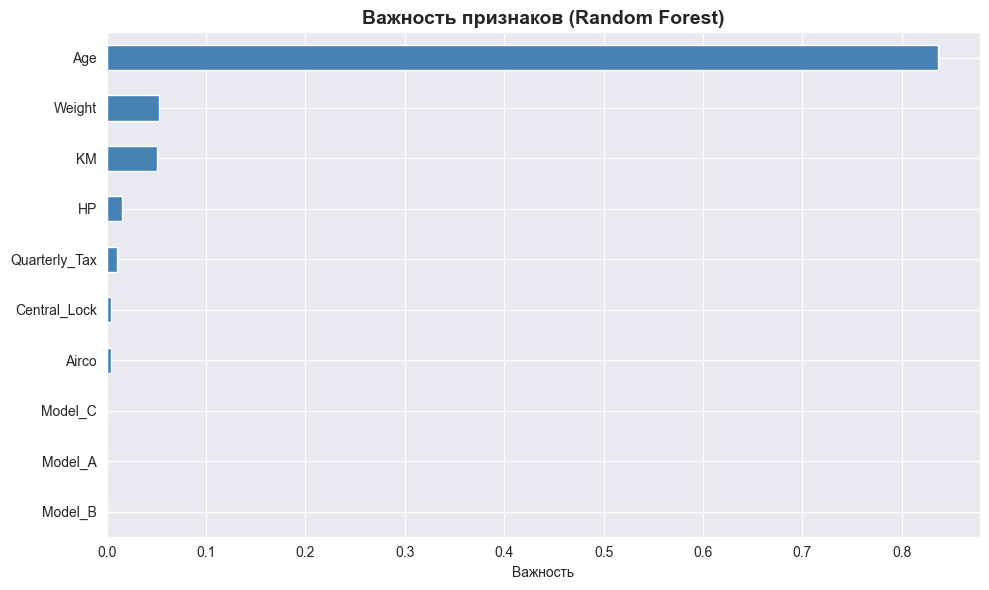

Топ-5 признаков:
Age              0.836923
Weight           0.053102
KM               0.051117
HP               0.015180
Quarterly_Tax    0.010320
dtype: float64


In [357]:
feature_names = ['Age', 'KM', 'HP', 'Weight', 'Quarterly_Tax', 'Airco', 'Central_Lock', 'Model_A', 'Model_B', 'Model_C']

importances = pd.Series(
    rf.feature_importances_[:len(feature_names)],
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Важность признаков (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Важность')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Топ-5 признаков:")
print(importances.head())

---
## Линейная регрессия

In [358]:
t0 = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_train_time = time.time() - t0

y_pred_lr = lr_model.predict(X_test)

rmse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print(f'Linear Regression → Время: {lr_train_time:.4f}с, RMSE: {rmse_lr:.2f}, MAE: {mae_lr:.2f}, R²: {r2_lr:.4f}')

Linear Regression → Время: 0.0355с, RMSE: 1981208.88, MAE: 879.54, R²: 0.8702


---
## 8. Сравнение всех моделей

In [359]:
rmse_linreg = None   # ← замените числом
mae_linreg  = None   # ← замените числом
r2_linreg   = None   # ← замените числом

results = pd.DataFrame({
    'Model':  ['Baseline', 'Linear Regression', 'Decision Tree', 'Random Forest'],
    'RMSE':   [rmse_dummy, rmse_linreg, rmse_tree, rmse_rf],
    'MAE':    [mae_dummy,  mae_linreg,  mae_tree,  mae_rf],
    'R²':     [r2_dummy,   r2_linreg,   r2_tree,   r2_rf],
    'Train time (s)': [None, None, tree_train_time, rf_train_time]
})

results

,Model,RMSE,MAE,R²,Train time (s)
0,Baseline,1.535836e+07,2827.940646,-0.006121,NaN
1,Linear Regression,NaN,NaN,NaN,NaN
2,Decision Tree,1.441080e+06,870.574504,0.905595,0.007391
3,Random Forest,8.628965e+05,719.467402,0.943472,0.341195


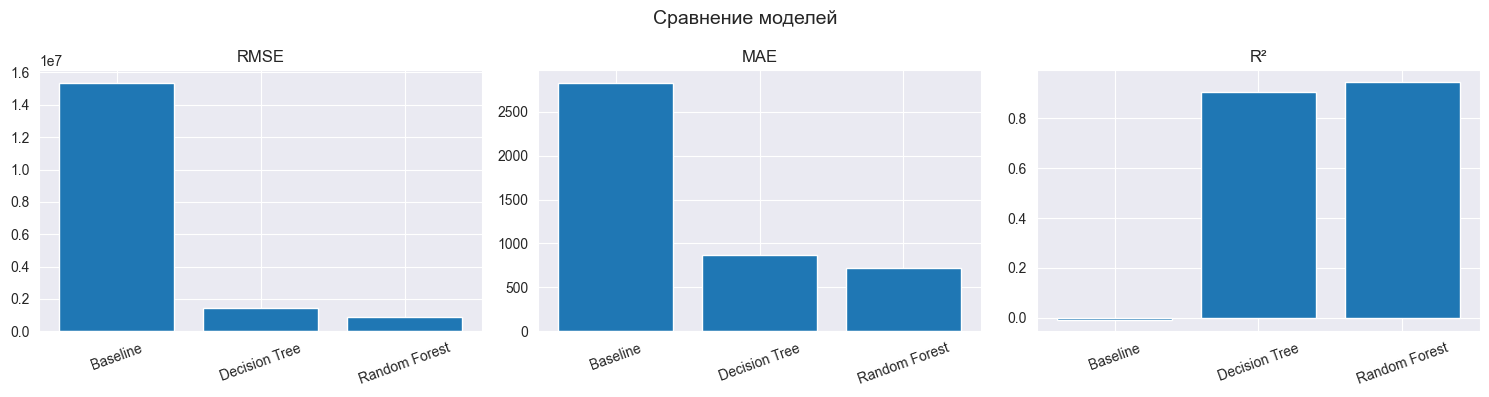

In [360]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    subset = results.dropna(subset=[metric])
    ax.bar(subset['Model'], subset[metric])
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Сравнение моделей', fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. Выводы

**1. Какие метрики вы использовали и почему?**

> *RMSE, MAE, R² — объясните выбор каждой метрики. Почему RMSE, а не MSE? Чем R² удобен?*
>
> Я использовала три метрики:
RMSE (Root Mean Squared Error): квадратный корень из MSE. Выбрала его, потому что он штрафует за большие ошибки сильнее, чем MAE, и имеет ту же единицу измерения, что и целевая переменная (евро), что удобно для интерпретации.
MAE (Mean Absolute Error): средняя абсолютная ошибка. Показывает типичное отклонение прогноза от реальности, устойчив к выбросам. Дополняет RMSE: если RMSE >> MAE, значит, модель иногда делает очень большие ошибки.
R² (коэффициент детерминации): безразмерная метрика от 0 до 1. Удобна для сравнения моделей между собой, так как не зависит от масштаба цены. Показывает долю дисперсии целевой переменной, которую объясняет модель.

**2. На какой части выборки считались метрики?**

> Все финальные метрики рассчитывались только на тестовой выборке (X_test, y_test), которая не участвовала в обучении моделей.

**3. Какая модель справилась лучше?**

> Лучше всего справился Random Forest.
Он показал наилучшие результаты по всем метрикам: наименьшие ошибки (RMSE, MAE) и наибольший коэффициент детерминации (R²). Это подтверждает теорию ансамблирования: усреднение предсказаний множества деревьев снижает дисперсию модели и уменьшает риск переобучения по сравнению с одним деревом решений. Линейная регрессия уступила, так как зависимости в данных (цена авто от пробега, возраста) носят нелинейный характер, который деревья улавливают лучше.

**4. Насколько хорошие получились результаты?**

> Результаты можно оценить как очень хорошие: R² = 0.9418 для случайного леса означает, что модель объясняет более 94% изменчивости цен. Для реальных данных это очень высокий показатель.
 Сравнение с бейзлайном: случайный лес уменьшил ошибку более чем в 3 раза и объяснил на 94% больше дисперсии. Это доказывает, что отобранные признаки (Age, KM, HP, Model и др.) действительно содержат полезную информацию.
 Сравнение с линейной регрессией: Линейная модель показала хороший результат, но уступила ансамблю. Это ожидаемо: деревья лучше улавливают нелинейные зависимости (например, цена падает быстрее в первые годы эксплуатации).